11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


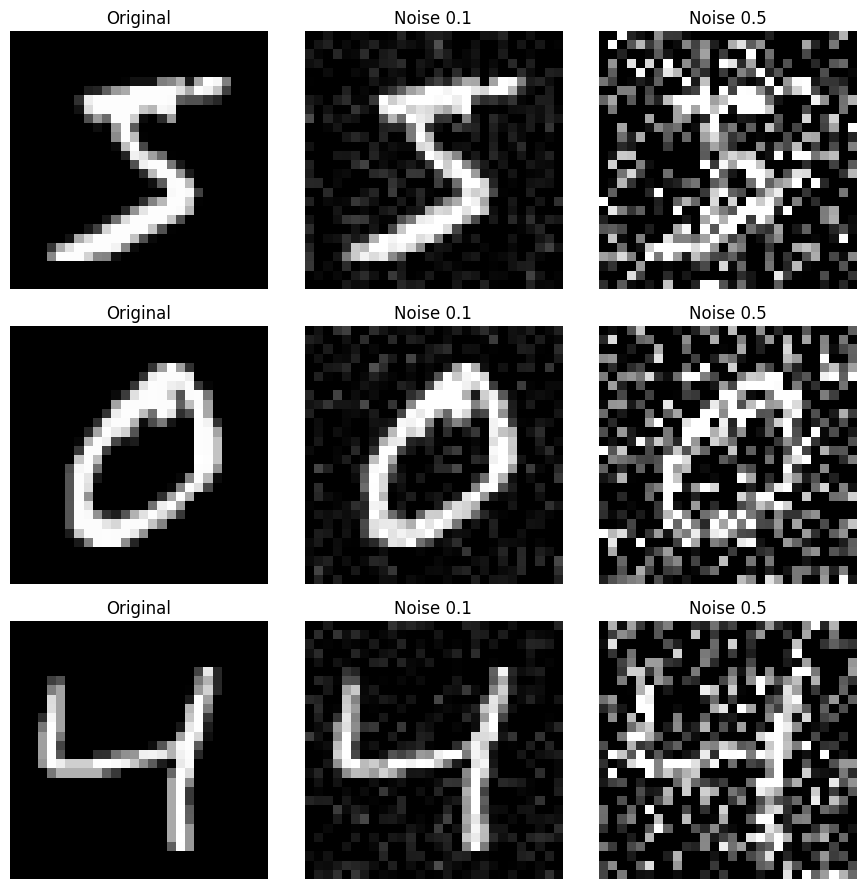

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load and preprocess MNIST
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# Generate noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5

x_train_noisy_low = x_train + noise_factor_low * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape
)

x_train_noisy_high = x_train + noise_factor_high * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape
)

x_test_noisy_low = x_test + noise_factor_low * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape
)

x_test_noisy_high = x_test + noise_factor_high * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape
)

# Clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)

x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)

# Visualize in a 3 x 3 grid
n = 3  # number of images to show
plt.figure(figsize=(9, 9))

for i in range(n):
    # Original image
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Low noise image
    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.1")
    plt.axis('off')

    # High noise image
    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.5")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [3]:
def build_encoder(input_shape=(28, 28, 1)):
    """
    Builds the encoder part of the convolutional autoencoder.
    Parameters:
    input_shape (tuple): Shape of the input image. Default is (28, 28, 1) for MNIST.
    Returns:
    input_img (Keras Input): Input layer of the model.
    encoded (Keras Tensor): Encoded representation after convolution and pooling.
    """
    input_img = Input(shape=input_shape, name="input")
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
    return input_img, encoded

In [4]:
def build_decoder(encoded_input):
    """
    Builds the decoder part of the convolutional autoencoder.
    Parameters:
    encoded_input (Keras Tensor): The output from the encoder.

    9

    6CS012 Tutorial - 7 Siman Giri

    Returns:
    decoded (Keras Tensor): The reconstructed output after upsampling and
    convolution.
    """
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
    return decoded

In [5]:
def build_autoencoder():
    """
    Constructs and compiles the full convolutional autoencoder by connecting encoder and
    decoder.
    Returns:
    autoencoder (Keras Model): Compiled autoencoder model.
    """
    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_output)
    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
    return autoencoder

In [6]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Build the autoencoder from previous steps
autoencoder = build_autoencoder()
# Train with noisy input and clean target
history = autoencoder.fit(
x_train_noisy_high, x_train,
epochs=10,
batch_size=128,
shuffle=True,
validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.1606 - val_loss: 0.1119
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1085 - val_loss: 0.1045
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.1038 - val_loss: 0.1015
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1014 - val_loss: 0.0997
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0999 - val_loss: 0.0991
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0989 - val_loss: 0.0984
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0980 - val_loss: 0.0970
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0973 - val_loss: 0.0973
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0967 - val_loss: 0.0959
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0961 - val_loss: 0.0955


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


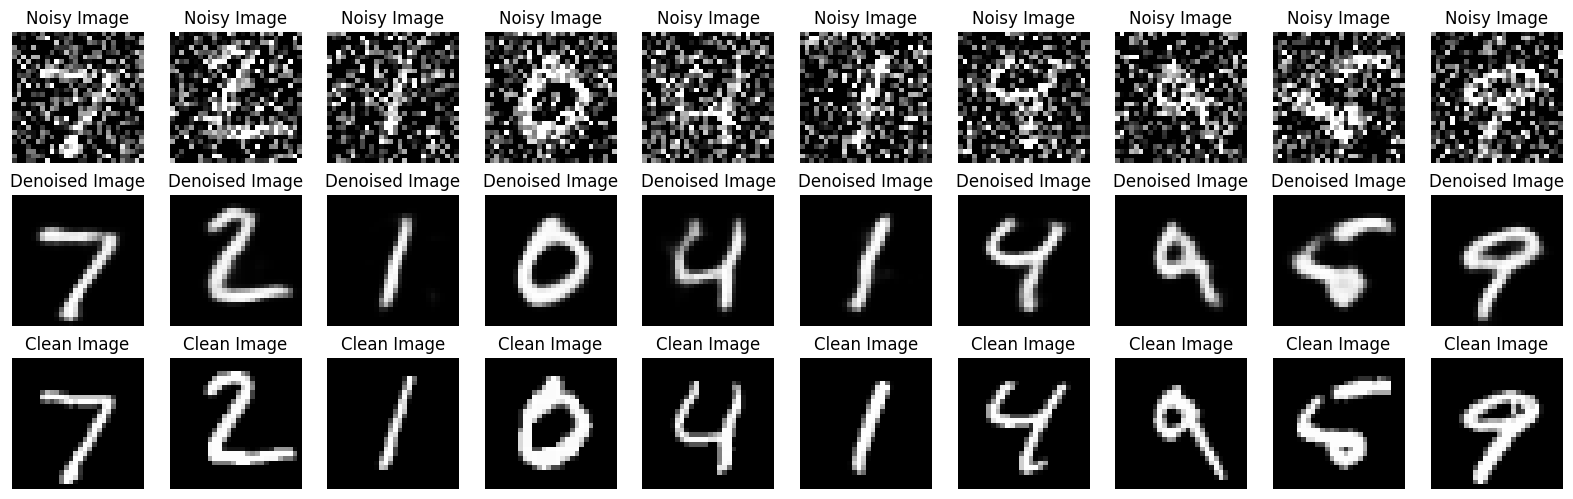

In [8]:
# Predict the denoised images from noisy test images
denoised_images = autoencoder.predict(x_test_noisy_high)

# Function to display images
def plot_images(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))
    for i in range(n):
        # Plot noisy images
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy Image")
        plt.axis('off')

        # Plot denoised images
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised Image")
        plt.axis('off')

        # Plot clean images
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean Image")
        plt.axis('off')
    plt.show()

# Display the first 10 images
plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

# **Exercise**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.optimizers import Adam

In [11]:
import os
import numpy as np
from PIL import Image

dataset_path = "/content/drive/MyDrive/AI ml/Data/DevanagariHandwrittenDigitDataset"

images = []
labels = []

img_size = 32

# Check dataset path exists
print("Dataset Path Exists:", os.path.exists(dataset_path))

for dataset_type_folder in os.listdir(dataset_path): # e.g., 'Test', 'Train'

    dataset_type_path = os.path.join(dataset_path, dataset_type_folder)

    if os.path.isdir(dataset_type_path):

        print("Reading Folder:", dataset_type_folder)

        for digit_folder_name in os.listdir(dataset_type_path): # e.g., 'digit_0', 'digit_1'

            digit_folder_path = os.path.join(dataset_type_path, digit_folder_name)

            if os.path.isdir(digit_folder_path):

                for img_name in os.listdir(digit_folder_path): # actual image files

                    img_path = os.path.join(digit_folder_path, img_name)

                    try:
                        img = Image.open(img_path).convert("L")
                        img = img.resize((img_size, img_size))

                        img_array = np.array(img)

                        images.append(img_array)
                        labels.append(digit_folder_name) # Capture the digit label

                    except Exception as e:
                        print("Error loading:", img_path)
                        print(e)

images = np.array(images)

print("Total Images Loaded:", len(images))

Dataset Path Exists: True
Reading Folder: Train
Reading Folder: Test
Total Images Loaded: 17679


In [12]:
##Normalizing the images
images = images.astype('float32') / 255.0

In [13]:
#Reshaping the images for CNN
images = images.reshape(-1, img_size, img_size, 1)

print(images.shape)

(17679, 32, 32, 1)


In [14]:
#Splitting the data
x_train, x_val = train_test_split(
    images,
    test_size=0.2,
    random_state=42
)


In [15]:
#adding noise to the image
noise_factor = 0.4

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_val_noisy = x_val + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_val.shape
)

# Clip values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_val_noisy = np.clip(x_val_noisy, 0., 1.)

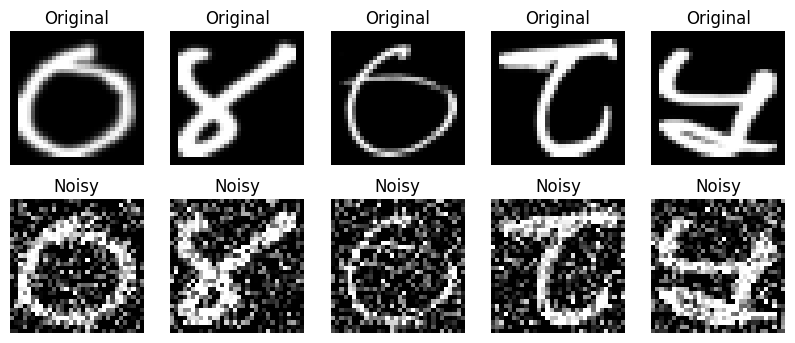

In [16]:
#visualize noisy images
plt.figure(figsize=(10,4))

for i in range(5):

    ax = plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].reshape(32,32), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    ax = plt.subplot(2,5,i+6)
    plt.imshow(x_train_noisy[i].reshape(32,32), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

plt.show()

In [17]:
#Building the denoising convulational autoencoder
input_img = Input(shape=(32,32,1))

#Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

#  Decoder
x = Conv2D(128, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3),
                 activation='sigmoid',
                 padding='same')(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer=Adam(),
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
#Training the model
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_val_noisy, x_val)
)

Epoch 1/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - loss: 0.3539 - val_loss: 0.2328
Epoch 2/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2055 - val_loss: 0.1920
Epoch 3/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1782 - val_loss: 0.1700
Epoch 4/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1658 - val_loss: 0.1614
Epoch 5/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1588 - val_loss: 0.1559
Epoch 6/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1538 - val_loss: 0.1517
Epoch 7/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1504 - val_loss: 0.1502
Epoch 8/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1479 - val_loss: 0.1471
Epoch 9/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1455 - val_loss: 0.1452
Epoch 10/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1439 - val_loss: 0.1444
Epoch 11/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1429 - val_loss: 0.1452
Epoch 12/20
111/111 ━━━━━━━━━━━━━━━━━━━━

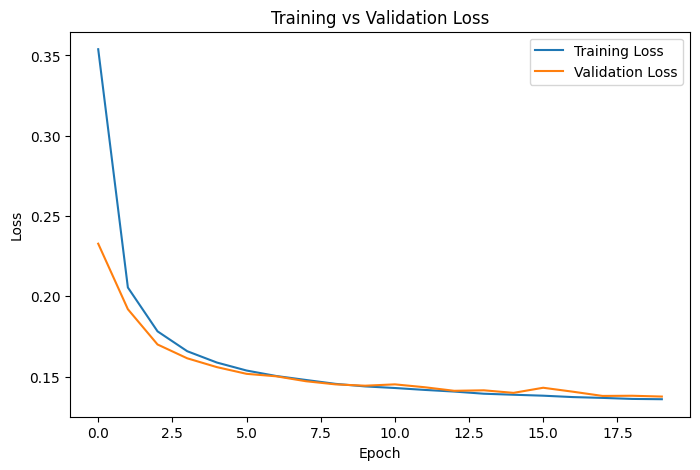

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [20]:
#Predicting denoised images
decoded_imgs = autoencoder.predict(x_val_noisy)

111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


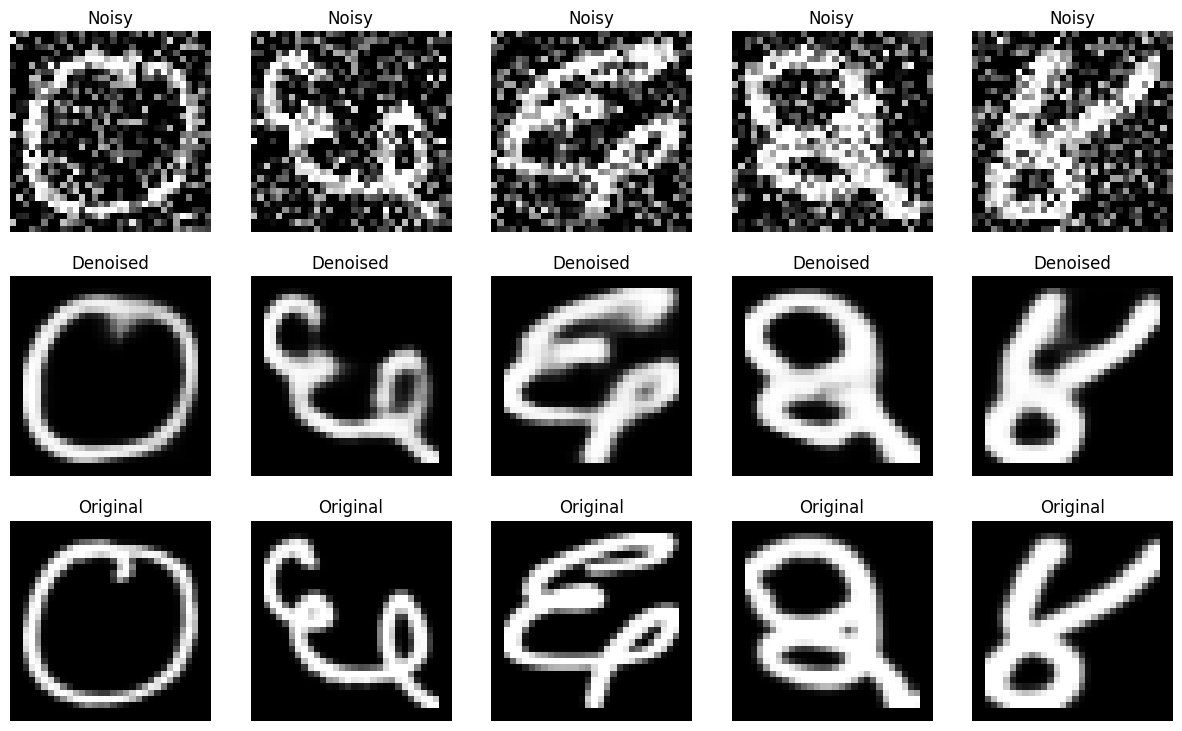

In [21]:
#visualizing results
n = 5

plt.figure(figsize=(15,9))

for i in range(n):

    # Noisy Image
    ax = plt.subplot(3,n,i+1)
    plt.imshow(x_val_noisy[i].reshape(32,32), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised Image
    ax = plt.subplot(3,n,i+n+1)
    plt.imshow(decoded_imgs[i].reshape(32,32), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

    # Original Image
    ax = plt.subplot(3,n,i+2*n+1)
    plt.imshow(x_val[i].reshape(32,32), cmap='gray')
    plt.title("Original")
    plt.axis("off")

plt.show()